## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
#importazione dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

40.0
[50.0, 49.28909952606635, 51.81598062953995, 51.86991869918699, 48.592411260709916, 49.55839057899902, 49.877149877149876, 50.66760365425158, 50.4, 47.83798576902025, 49.48250369640217, 50.694755714926046, 51.54130702836005, 47.34244495064541, 50.916784203102964, 48.18959842001317, 50.37037037037037, 49.680418361417786, 51.78375411635565, 50.62402496099844, 50.4693675889328, 49.88235294117647, 49.865229110512125, 50.17189514396219, 50.10296540362438, 49.594621316986355, 49.21087659250808, 49.8626625160227, 49.12590499735123, 49.752770673486786, 49.876380418658314, 50.13558781304833, 50.34770514603616, 50.247265098156745, 49.46909090909091, 50.035325702981496, 50.899848880340706, 49.057612618633875, 49.284040614423326, 51.04008117706748, 51.261439525105125, 49.143339768339764, 50.84805653710247, 50.58674643350207, 50.91072633235889, 50.186895338610384, 49.741879974187995, 49.92631578947368, 50.16491445062874, 50.0, 50.133597229094505, 50.55787328999709, 49.36720905890189, 51.068994

Text(0, 0.5, 'frequenze')

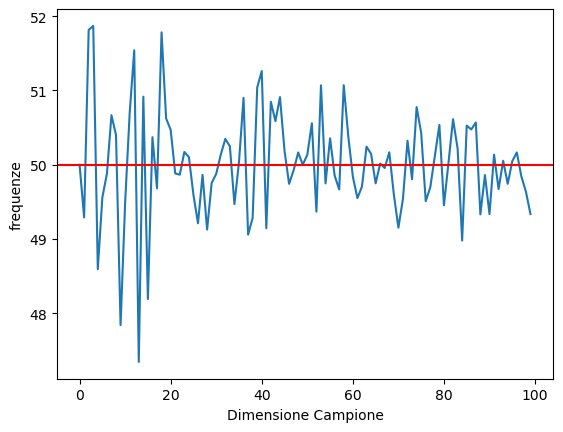

In [14]:
def lanciomoneta(volte):

    count_testa = 0

    i = 0
    
    while i < volte:

        ris = np.random.randint(0,2,1)

        if ris == 1:
            count_testa +=1

        i+=1

    return (count_testa/volte)*100


print(lanciomoneta(5))

campione = np.linspace(10,20000,100,dtype=int)
frequenze = []

for item in campione:
    frequenze.append(float(lanciomoneta(item)))

print(frequenze)

plt.plot(frequenze, scalex = len(campione), scaley = frequenze)
plt.axhline(50, color="red")
plt.xlabel("Dimensione Campione")
plt.ylabel("frequenze")

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [37]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#a)

df.shape

In [18]:
#b)

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
#c)

df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [23]:
#d)

df.duplicated().sum()

np.int64(0)

In [ ]:

#e)

#Ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio

df["Age"] = df["Age"].fillna(float(df["Age"].mean()))

#Calcola l'età media dei passeggeri per ogni classe (`Pclass`)

df.groupby("Pclass")["Age"].mean()



Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

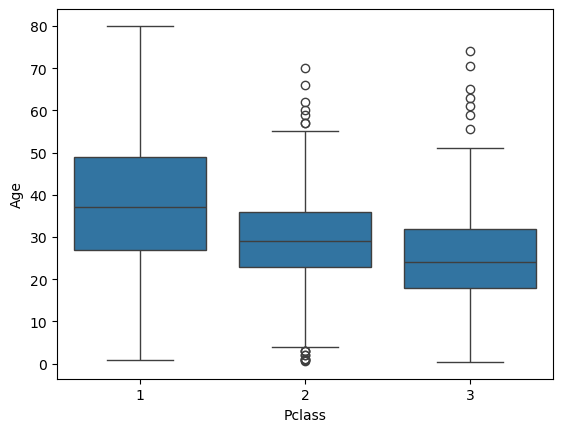

In [41]:
#f)

eta_medie = df.groupby("Pclass")["Age"].mean()

sns.boxplot(data=df, x="Pclass", y="Age")

<Axes: xlabel='Pclass', ylabel='Age'>

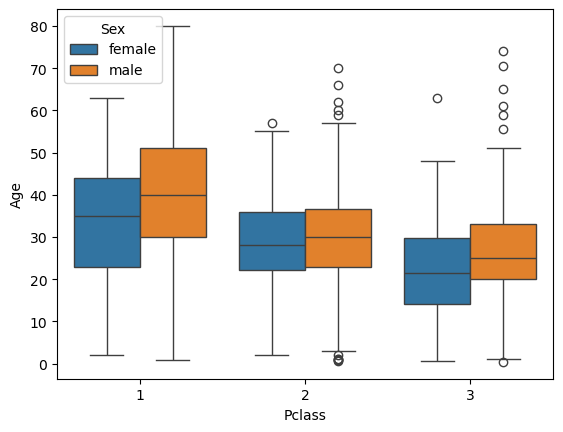

In [42]:
#g)

sns.boxplot(data=df, x="Pclass", y="Age",hue="Sex" )

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()